## Churn prediction project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 3.2 Data preparation

- Download the data, read it with pandas
- Look at the data
- Make column names and values look uniform
- Check if all the columns read correctly
- Check if the churn variable needs any preparation

In [2]:
df = pd.read_csv('telco_customer_churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# not all colums appear so:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [6]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,7033,7034,7035,7036,7037,7038,7039,7040,7041,7042
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu,9305-cdskc,1452-kiovk,6713-okomc,7892-pookp,6388-tabgu,...,9767-fflem,0639-tsiqw,8456-qdavc,7750-eyxwz,2569-wgero,6840-resvb,2234-xaduh,4801-jzazl,8361-ltmkd,3186-ajiek
gender,female,male,male,male,female,female,male,female,female,male,...,male,female,male,female,female,male,female,female,male,male
seniorcitizen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
partner,yes,no,no,no,no,no,no,no,yes,no,...,no,no,no,no,no,yes,yes,yes,yes,no
dependents,no,no,no,no,no,no,yes,no,no,yes,...,no,no,no,no,no,yes,yes,yes,no,no
tenure,1,34,2,45,2,8,22,10,28,62,...,38,67,19,12,72,24,72,11,4,66
phoneservice,no,yes,yes,no,yes,yes,yes,no,yes,yes,...,yes,yes,yes,no,yes,yes,yes,no,yes,yes
multiplelines,no_phone_service,no,no,no_phone_service,no,yes,yes,no_phone_service,yes,no,...,no,yes,no,no_phone_service,no,yes,yes,no_phone_service,yes,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic,fiber_optic,fiber_optic,dsl,fiber_optic,dsl,...,fiber_optic,fiber_optic,fiber_optic,dsl,no,dsl,fiber_optic,dsl,fiber_optic,fiber_optic
onlinesecurity,no,yes,yes,yes,no,no,no,yes,no,yes,...,no,yes,no,no,no_internet_service,yes,no,yes,no,yes


In [7]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')
tc.isnull().sum()

df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df[tc.isnull()][['totalcharges', 'customerid']]

,totalcharges,customerid
488,0.0,4472-lvygi
753,0.0,3115-czmzd
936,0.0,5709-lvoeq
1082,0.0,4367-nuyao
1340,0.0,1371-dwpaz
3331,0.0,7644-omvmy
3826,0.0,3213-vvolg
4380,0.0,2520-sgtta
5218,0.0,2923-arzlg
6670,0.0,4075-wkniu


In [8]:
df.churn = (df.churn == 'yes').astype(int)

## 3.3 Setting up the validation framework

- Perform the train/valid/test split with Scikit-learn

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [11]:
df_full_train, df_test = train_test_split(df, train_size= 0.8, test_size= 0.2, random_state=1)
df_train, df_validation = train_test_split(df_full_train, train_size = 0.75, test_size = 0.25, random_state=1)

In [12]:
len(df_train), len(df_validation), len(df_test)

(4225, 1409, 1409)

In [13]:
df_train = df_train.reset_index(drop=True)
df_validation = df_validation.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_validation = df_validation.churn.values
y_test = df_test.churn.values

In [14]:
del df_train['churn']
del df_validation['churn']
del df_test['churn']

## 3.4 EDA

- Check missing values
- Look at the target variable (churn)
- Look at the numerical and categorical variables 

In [15]:
df_full_train = df_full_train.reset_index(drop=True)

In [16]:
df_full_train.isnull().sum()

# df_full_train.churn.value_counts()
print(df_full_train.churn.value_counts(normalize=True)) # churn rate
print(df_full_train.churn.mean().round(5))

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64
0.26997


In [17]:
globel_churn_rate = df_full_train.churn.mean().round(5)

In [18]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [19]:
# take numerical features
numerical = ['tenure', 'monthlycharges', 'totalcharges']

# take categorical features
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
               'phoneservice', 'multiplelines', 'internetservice',
               'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
               'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
               'paymentmethod']

In [20]:
df_full_train[categorical]
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## 3.5 Feature Importance: Churn rate & Risk ratio
Feature importance analysis (part of EDA) - identifying which features affect our target variable

- Churn rate
- Risk ratio
- Mutual information - later

In [21]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


**Churn rate**

In [22]:
globel_churn = df_full_train.churn.mean()

churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()

In [23]:
df_full_train.partner.value_counts()

partner
no     2932
yes    2702
Name: count, dtype: int64

In [24]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()

**Risk Difference**

**Global - Group:**
 
- If it is less than 0, more likely to churn.
- Else, if it is greater than 0, less likely to churn.


In [25]:
# as u see the risk difference is tiny, so the gender doesn't really matter in churn

print(globel_churn - churn_female)
print(globel_churn - churn_male)

print("-----------------------------")

# as u see the risk difference is NOT tiny, so if the person has a partner that's really matter in churn

print(globel_churn - churn_partner)
print(globel_churn - churn_no_partner)

# so perhaps the partner variable is more important for prediciting churn than the gender variable, So i want to measure the feature importance

-0.006855983216553063
0.006754520462819769
-----------------------------
0.06493474245795922
-0.05984095297455855


**Risk ratio**

**Risk = (Group / Global)**

- If it's GREATER than 1, it's more likely to churn
- If it's LESS than 1, it's less likely to churn

In [26]:
print(churn_no_partner / globel_churn)
print(churn_partner / globel_churn)

1.2216593879412643
0.7594724924338315


**Risk Difference And Risk ratio, they are very similar, but there's an important difference**

![chur_rate](churn-rate.png)

In [27]:
import duckdb

query = f"""

select gender,
       avg(churn),
       avg(churn) - {globel_churn} as Risk_diff,
       avg(churn) - {globel_churn} as Risk_ratio
       from df_full_train
       group by gender
"""

r = duckdb.query(query).df()

# Or use:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count']) # return dataFrame
df_group['risk_diff'] = df_group['mean'] - globel_churn
df_group['risk_ratio'] = df_group['mean'] / globel_churn

df_group

,mean,count,risk_diff,risk_ratio
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


In [28]:
# for add all categoricals variables (apply risk difference and risk ratio

from IPython.display import display ## to print multiple (image, videos, DataFrame in single cell

for c in categorical:

    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['risk_diff'] = df_group['mean'] - globel_churn
    df_group['risk_ratio'] = df_group['mean'] / globel_churn
    display(df_group)
    print("\n")

gender


,mean,count,risk_diff,risk_ratio
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,risk_diff,risk_ratio
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


,mean,count,risk_diff,risk_ratio
partner,,,,
no,0.329809,2932,0.059841,1.221659
yes,0.205033,2702,-0.064935,0.759472




dependents


,mean,count,risk_diff,risk_ratio
dependents,,,,
no,0.313760,3968,0.043792,1.162212
yes,0.165666,1666,-0.104302,0.613651




phoneservice


,mean,count,risk_diff,risk_ratio
phoneservice,,,,
no,0.241316,547,-0.028652,0.893870
yes,0.273049,5087,0.003081,1.011412




multiplelines


,mean,count,risk_diff,risk_ratio
multiplelines,,,,
no,0.257407,2700,-0.012561,0.953474
no_phone_service,0.241316,547,-0.028652,0.893870
yes,0.290742,2387,0.020773,1.076948




internetservice


,mean,count,risk_diff,risk_ratio
internetservice,,,,
dsl,0.192347,1934,-0.077621,0.712482
fiber_optic,0.425171,2479,0.155203,1.574895
no,0.077805,1221,-0.192163,0.288201




onlinesecurity


,mean,count,risk_diff,risk_ratio
onlinesecurity,,,,
no,0.420921,2801,0.150953,1.559152
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.153226,1612,-0.116742,0.567570




onlinebackup


,mean,count,risk_diff,risk_ratio
onlinebackup,,,,
no,0.404323,2498,0.134355,1.497672
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.217232,1915,-0.052736,0.804660




deviceprotection


,mean,count,risk_diff,risk_ratio
deviceprotection,,,,
no,0.395875,2473,0.125907,1.466379
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.230412,1940,-0.039556,0.853480




techsupport


,mean,count,risk_diff,risk_ratio
techsupport,,,,
no,0.418914,2781,0.148946,1.551717
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.159926,1632,-0.110042,0.592390




streamingtv


,mean,count,risk_diff,risk_ratio
streamingtv,,,,
no,0.342832,2246,0.072864,1.269897
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.302723,2167,0.032755,1.121328




streamingmovies


,mean,count,risk_diff,risk_ratio
streamingmovies,,,,
no,0.338906,2213,0.068938,1.255358
no_internet_service,0.077805,1221,-0.192163,0.288201
yes,0.307273,2200,0.037305,1.138182




contract


,mean,count,risk_diff,risk_ratio
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,risk_diff,risk_ratio
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,risk_diff,risk_ratio
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## 3.6 Feature Importance: Mutual Information

Mutual information - concept from information theory,
it tells us how much we can learn about one variable if we know the value of another

What is Mutual Information?In machine learning, Mutual Information (MI) is a powerful metric used for feature selection. In plain terms, it measures how much information the presence (or absence) of one variable tells you about another variable.Imagine you are trying to guess what a friend is wearing (the Target variable, $Y$).If you learn it's a Tuesday (Feature 1, $X_1$), that probably doesn't help you guess their outfit. The mutual information is zero.If you learn it's snowing heavily outside (Feature 2, $X_2$), that immediately rules out shorts and t-shirts, giving you a strong clue they are wearing a coat. The mutual information is high.Mutual Information measures this reduction in uncertainty.

In [29]:
from sklearn.metrics import mutual_info_score

In [30]:
print(f"Contract & Churn: {mutual_info_score(df_full_train.churn, df_full_train.contract)}") # high risk
print(f"Gender & Churn:   {mutual_info_score(df_full_train.churn, df_full_train.gender)}") # low risk

Contract & Churn: 0.0983203874041556
Gender & Churn:   0.0001174846211139946


In [31]:
def mutual_info_churn_score(series):
    return mutual_info_score(df_full_train.churn, series)
    
mutual_information = df_full_train[categorical].apply(mutual_info_churn_score)
mutual_information.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

## 

## 3.7 Feature importance: Correlation

How about numerical columns? (How numerical variables affect on target variable).

```
Correlation coefficient measures the degree of dependency between two variables. This value is negative if one variable grows while the other decreases, and it is positive if both variables increase. Depending on its size, the dependency between both variables could be low, moderate, or strong. It allows measuring the importance of numerical variables.

If r is correlation coefficient, then the correlation between two variables is:

LOW when r is between [0, -0.2) or [0, 0.2)
MEDIUM when r is between [-0.2, -0.5) or [0.2, 0.5)
STRONG when r is between [-0.5, -1.0] or [0.5, 1.0]
Positive Correlation vs. Negative Correlation

When r is positive, an increase in x will increase y.
When r is negative, an increase in x will decrease y.
When r is 0, a change in x does not affect y.

```
- **Correlation coefficient: to measure the degree of dependency between 2 variables**
<img src='correlation.png' width=50%>
<img src='correlation2.png' width=50%>

In [32]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

```
- tenure           -0.351885 -> More tenure         -> Decrease churn rate (Negative)
- monthlycharges    0.196805 -> More monthlycharges -> Increase churn rate (Positive)
- totalcharges     -0.196353 -> More totalcharges   -> Decrease churn rate (Negative)

```

In [33]:
# print(df_full_train[df_full_train.tenure > 2].churn.mean())

print(df_full_train[df_full_train.tenure <= 2].churn.mean())
print(df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean())
print(df_full_train[df_full_train.tenure >= 12].churn.mean())

0.5953420669577875
0.3994413407821229
0.17986881937436933


<img src='correlation3.png' width='40%'>

In [34]:

print(df_full_train[df_full_train.monthlycharges <= 20].churn.mean())
print(df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean())
print(df_full_train[df_full_train.monthlycharges > 50].churn.mean())

0.08795411089866156
0.18340943683409436
0.32499341585462205


<img src='correlation4.png' width='40%'>

<img src='correlation5.png' width='40%'>

In [35]:
# if we don't care about the direction (just importance)
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

## 3.8 One-hot encoding 
- Use Scikit-Learn to encode categorical features.

```
The .fit() method in scikit-learn's DictVectorizer "learns" the list of feature names and their corresponding column indices.

Essentially, it scans your list of dictionaries to build a internal vocabulary (mapping keys to positions) so it knows how to structure the final numerical matrix. 
🔍 Key Functions of .fit() Identifies All Keys: It scans every dictionary in your input list to find every unique key.

Assigns Indices: Each unique key is assigned a specific column number in the output matrix.

One-Hot Encoding Setup: If a value is a string, .fit() treats it as a categorical feature. It creates a separate column for every unique "key=value" pair.

Numerical Handling: If a value is a number, it simply reserves one column for that key.
```
<img src='one-hot-encoding.png' width='40%'>

In [36]:
# DictVectorizer for apply One-Hot encoding
from sklearn.feature_extraction import DictVectorizer

In [37]:
df_train[['gender', 'contract']].iloc[:100] 

,gender,contract
0,female,two_year
1,male,month-to-month
2,female,month-to-month
3,female,month-to-month
4,female,two_year
...,...,...
95,male,one_year
96,female,month-to-month
97,male,month-to-month
98,male,one_year


In [38]:
dicts = df_train[['gender', 'contract']].iloc[:100].to_dict(orient='records')

In [39]:
# take an instance from DictVectorizer class (will not use sparse matrix here)
dv = DictVectorizer(sparse=False)

dv.fit(dicts) # understand it above

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


<img src='one-hot-encoding1.png' width='30%'>

In [40]:
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'gender=female', 'gender=male'], dtype=object)

In [41]:
dv.transform(dicts)

# Note: this for cateogrical variables, and if I have numerical variable it will leave as it is

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0.

In [42]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
train_dv = DictVectorizer(sparse=False)
train_dv.fit(train_dicts)

print(train_dv.get_feature_names_out())
print("\n")

# transforme to features matrix
print(train_dv.transform(train_dicts))
# print(train_dv.transform(train_dicts[:5])[0])

['contract=month-to-month' 'contract=one_year' 'contract=two_year'
 'dependents=no' 'dependents=yes' 'deviceprotection=no'
 'deviceprotection=no_internet_service' 'deviceprotection=yes'
 'gender=female' 'gender=male' 'internetservice=dsl'
 'internetservice=fiber_optic' 'internetservice=no' 'monthlycharges'
 'multiplelines=no' 'multiplelines=no_phone_service' 'multiplelines=yes'
 'onlinebackup=no' 'onlinebackup=no_internet_service' 'onlinebackup=yes'
 'onlinesecurity=no' 'onlinesecurity=no_internet_service'
 'onlinesecurity=yes' 'paperlessbilling=no' 'paperlessbilling=yes'
 'partner=no' 'partner=yes' 'paymentmethod=bank_transfer_(automatic)'
 'paymentmethod=credit_card_(automatic)' 'paymentmethod=electronic_check'
 'paymentmethod=mailed_check' 'phoneservice=no' 'phoneservice=yes'
 'seniorcitizen' 'streamingmovies=no'
 'streamingmovies=no_internet_service' 'streamingmovies=yes'
 'streamingtv=no' 'streamingtv=no_internet_service' 'streamingtv=yes'
 'techsupport=no' 'techsupport=no_interne

In [43]:
# Or use this

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
train_dv = DictVectorizer(sparse=False)

X_train = train_dv.fit_transform(train_dicts)

In [44]:
X_train.shape

(4225, 45)

In [45]:
# So here the Whole Process

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
train_dv = DictVectorizer(sparse=False)
X_train = train_dv.fit_transform(train_dicts)


validation_dicts = df_validation[categorical + numerical].to_dict(orient='records')
validation_dv = DictVectorizer(sparse=False)
X_validation = validation_dv.fit_transform(validation_dicts)

## 3.9 Logistic Regression
- Binary classification
- Linear vs logistic regression

<img src='logistic-regression.png' width='40%' >

<img src='logistic-regression.png' width='40%'>

[1.23394576e-04 1.76855619e-04 2.53472935e-04 3.63270313e-04
 5.20604074e-04 7.46028834e-04 1.06895950e-03 1.53146171e-03
 2.19363336e-03 3.14121328e-03 4.49627316e-03 6.43210847e-03
 9.19370537e-03 1.31253183e-02 1.87065100e-02 2.65969936e-02
 3.76878905e-02 5.31511364e-02 7.44679452e-02 1.03400451e-01
 1.41851065e-01 1.91545349e-01 2.53506017e-01 3.27392983e-01
 4.10959566e-01 5.00000000e-01 5.89040434e-01 6.72607017e-01
 7.46493983e-01 8.08454651e-01 8.58148935e-01 8.96599549e-01
 9.25532055e-01 9.46848864e-01 9.62312109e-01 9.73403006e-01
 9.81293490e-01 9.86874682e-01 9.90806295e-01 9.93567892e-01
 9.95503727e-01 9.96858787e-01 9.97806367e-01 9.98468538e-01
 9.98931040e-01 9.99253971e-01 9.99479396e-01 9.99636730e-01
 9.99746527e-01 9.99823144e-01 9.99876605e-01]
[-9.   -8.64 -8.28 -7.92 -7.56 -7.2  -6.84 -6.48 -6.12 -5.76 -5.4  -5.04
 -4.68 -4.32 -3.96 -3.6  -3.24 -2.88 -2.52 -2.16 -1.8  -1.44 -1.08 -0.72
 -0.36  0.    0.36  0.72  1.08  1.44  1.8   2.16  2.52  2.88  3.24  3.6
  3

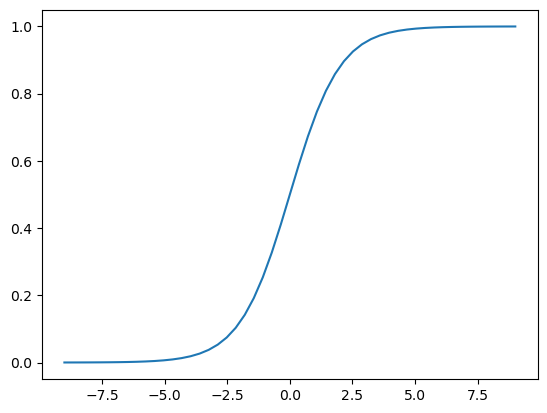

In [46]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-9, 9, 51)

print(sigmoid(z)); print(z) # look how the values squished or map from 0 to 1

print("\n\n")
plt.plot(z, sigmoid(z))

In [47]:
def linear_regression(xi):

    result = w0

    for i in len(xi):
        result += xi[i] * w[i]

    return result

    
def logistic_regression(xi):

    score = w0

    for i in len(xi):
        score += xi[i] * w[i]

    score = sigmoid(score)
    
    return score

## 3.10 Training Logistic regression with Scikit-Learn 

- Train a model with scikit-learn
- Apply it to the validation dataset
- Calculate the accuracy

In [48]:
from sklearn.linear_model import LogisticRegression

In [49]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_train)

/home/issa/miniconda3/envs/mzc/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [50]:
# the weights
print(model.coef_[0].round(3))
print("\n\n")

# the bias
print(model.intercept_[0])

[ 0.564 -0.154 -0.519 -0.013 -0.095  0.071 -0.098 -0.082 -0.033 -0.076
 -0.354  0.343 -0.098  0.002 -0.251  0.162 -0.02   0.066 -0.098 -0.076
  0.251 -0.098 -0.261 -0.228  0.119 -0.121  0.012 -0.095 -0.03   0.045
 -0.028  0.162 -0.271  0.221 -0.097 -0.098  0.087 -0.05  -0.098  0.039
  0.194 -0.098 -0.205 -0.072  0.   ]



-0.1109287445794238


In [51]:
# Hard prediction
print(model.predict(X_train))

# soft prediction
print(model.predict_proba(X_train))

[0 1 1 ... 1 0 1]
[[0.91088688 0.08911312]
 [0.33128828 0.66871172]
 [0.36229559 0.63770441]
 ...
 [0.48776317 0.51223683]
 [0.96993479 0.03006521]
 [0.2971009  0.7028991 ]]


<img src='logistic-regression2.png' height='20%' widht='20%'>

In [52]:
model.predict_proba(X_train)[:, 1:]

array([[0.08911312],
       [0.66871172],
       [0.63770441],
       ...,
       [0.51223683],
       [0.03006521],
       [0.7028991 ]], shape=(4225, 1))

In [53]:
y_prediction = model.predict_proba(X_validation)[:, 1]
churn_decision = (y_prediction >= 0.5)

df_validation[churn_decision].customerid # those are the people we will send to them promotional email (discount)

y_prediction = model.predict_proba(X_validation)[:, 1]
print(y_prediction)

[0.00786347 0.20992803 0.2237105  ... 0.15014869 0.77668113 0.81035774]


In [54]:
# to actually compute how well the model is

(y_validation == churn_decision.astype(int)).mean()

np.float64(0.801277501774308)

In [55]:
# Best approach: Initialize with data
df_predicit = pd.DataFrame({
    'probability': y_prediction,
    'prediction': churn_decision.astype(int),
    'actual': y_validation
})

df_predicit['correct'] = df_predicit.prediction == df_predicit.actual

df_predicit

,probability,prediction,actual,correct
0,0.007863,0,0,True
1,0.209928,0,0,True
2,0.223710,0,0,True
3,0.561123,1,1,True
4,0.219586,0,0,True
...,...,...,...,...
1404,0.297790,0,0,True
1405,0.035463,0,1,False
1406,0.150149,0,0,True
1407,0.776681,1,1,True


In [56]:
df_predicit.correct.mean()

np.float64(0.801277501774308)

## 3.11 Model Interpretation

- Look at coefficients.
- Train a smaller model with fewer features.

In [57]:
a = [1,2,3,4]
b = "abcd" # any collection of elements

print(list(zip(a, b)))
print(dict(zip(a, b)))

[(1, 'a'), (2, 'b'), (3, 'c'), (4, 'd')]
{1: 'a', 2: 'b', 3: 'c', 4: 'd'}


In [58]:
dict(zip(train_dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.564),
 'contract=one_year': np.float64(-0.154),
 'contract=two_year': np.float64(-0.519),
 'dependents=no': np.float64(-0.013),
 'dependents=yes': np.float64(-0.095),
 'deviceprotection=no': np.float64(0.071),
 'deviceprotection=no_internet_service': np.float64(-0.098),
 'deviceprotection=yes': np.float64(-0.082),
 'gender=female': np.float64(-0.033),
 'gender=male': np.float64(-0.076),
 'internetservice=dsl': np.float64(-0.354),
 'internetservice=fiber_optic': np.float64(0.343),
 'internetservice=no': np.float64(-0.098),
 'monthlycharges': np.float64(0.002),
 'multiplelines=no': np.float64(-0.251),
 'multiplelines=no_phone_service': np.float64(0.162),
 'multiplelines=yes': np.float64(-0.02),
 'onlinebackup=no': np.float64(0.066),
 'onlinebackup=no_internet_service': np.float64(-0.098),
 'onlinebackup=yes': np.float64(-0.076),
 'onlinesecurity=no': np.float64(0.251),
 'onlinesecurity=no_internet_service': np.float64(-0.098),
 'onlinesecurity=yes

In [59]:
# apply this for simplicty and to understand well
small = ['contract', 'tenure', 'monthlycharges']
df_train[small]

,contract,tenure,monthlycharges
0,two_year,72,115.50
1,month-to-month,10,95.25
2,month-to-month,5,75.55
3,month-to-month,5,80.85
4,two_year,18,20.10
...,...,...,...
4220,one_year,52,80.85
4221,month-to-month,18,25.15
4222,month-to-month,2,90.00
4223,two_year,27,24.50


In [60]:
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [61]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_validation[small].to_dict(orient='records')

In [63]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

,"dtype dtype: dtype, default=np.float64The type of feature values. Passed to Numpy array/scipy.sparse matrixconstructors as the dtype argument.",<class 'numpy.float64'>
,"separator separator: str, default=""=""Separator string used when constructing new features for one-hotcoding.",'='
,"sparse sparse: bool, default=TrueWhether transform should produce scipy.sparse matrices.",False
,"sort sort: bool, default=TrueWhether ``feature_names_`` and ``vocabulary_`` should besorted when fitting.",True


In [64]:
dv_small.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'monthlycharges', 'tenure'], dtype=object)

In [67]:
X_train_small = dv_small.transform(dicts_train_small)
X_train_small

array([[  0.  ,   0.  ,   1.  , 115.5 ,  72.  ],
       [  1.  ,   0.  ,   0.  ,  95.25,  10.  ],
       [  1.  ,   0.  ,   0.  ,  75.55,   5.  ],
       ...,
       [  1.  ,   0.  ,   0.  ,  90.  ,   2.  ],
       [  0.  ,   0.  ,   1.  ,  24.5 ,  27.  ],
       [  1.  ,   0.  ,   0.  ,  80.85,   9.  ]], shape=(4225, 5))

In [68]:
model_small = LogisticRegression()
model_small.fit(X_train_small, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [69]:
w0 = model_small.intercept_[0]
ws = model_small.coef_[0]

In [70]:
print(w0)
print(ws)

-2.477957595829565
[ 0.9711394  -0.02379507 -0.94828863  0.02748534 -0.03619005]


In [71]:
dict(zip(dv_small.get_feature_names_out(), ws.round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

<img src='logistic-regression3.png' width='40%' >

<img src='logistic-regression4.png' width='50%' >

In [72]:
customer = [1, 0, 0, 50, 5]
r = 0.0

for v in range(len(customer)):
    r += customer[v] * ws[v]    

r + w0

np.float64(-0.31350149653285)

In [73]:
# the probability of churning is
sigmoid(_)

np.float64(0.42226029418410266)

## 3.12 Using The Model

In [111]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')
dicts_test = df_test[categorical + numerical].to_dict(orient='records')

In [112]:
dv = DictVectorizer(sparse=False)

X_full_train = dv.fit_transform(dicts_full_train)
y_full_train = df_full_train.churn.values

# Use ONLY .transform() for the test set!
X_test = dv.transform(dicts_test)

In [113]:
model = LogisticRegression(max_iter=1000)
model.fit(X_full_train, y_full_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [114]:
y_prediction = model.predict_proba(X_test)[:, 1]

In [115]:
churn_decision = (y_prediction >= 0.5)

In [116]:
(churn_decision == y_test).mean()

np.float64(0.8105039034776437)

In [119]:
customer = dicts_test[10]
customer

{'gender': 'male',
 'seniorcitizen': 1,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'no',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'no',
 'onlinebackup': 'yes',
 'deviceprotection': 'no',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'mailed_check',
 'tenure': 32,
 'monthlycharges': 93.95,
 'totalcharges': 2861.45}

In [128]:
X_small = dv.transform([customer])
X_small

array([[1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 9.39500e+01, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 3.20000e+01, 2.86145e+03]])

In [129]:
X_small.shape

(1, 45)

In [136]:
model.predict_proba(X_small)[:, 1]
# so we predict he will not churn

array([0.47632824])

In [139]:
# also the actual y, he will Not churn
y_test[10]

np.int64(0)

## 3.13 Summary

- Feature importance - risk, mutual information, correlation
- One-hot encoding can be implemented with DictVectorizer
- Logistic regression - linear model like linear regression, but with sigmoid function
- Output of log reg - probability
- Interpretation of weights is similiar to linear regression

## 3.14 Explore More

Use scikit-learn in project of last week

- Re-implement train/val/test split using scikit-learn in the project from the last week.
- Also, instead of our own linear regression, use LinearRegression (not regularized) and RidgeRegression (regularized). Find the best regularization parameter for Ridge.
  
- There are other ways to implement one-hot encoding. E.g. using the OneHotEncoding class. Check how to use it [here](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/notebook-scaling-ohe.ipynb).
- Sometimes numerical features require scaling, especially for iterative solves like "lbfgs". Check how to use StandardScaler for that [here](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/03-classification/notebook-scaling-ohe.ipynb).